In [10]:
# Setting up the file path
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)
# Import Packages
from Input_Output_Rxn_Networks.IOCRN_MassAction import IOCRN_MassAction
from Input_Output_Rxn_Networks.CRNGenerator import CRNGenerator
from Input_Output_Rxn_Networks.ParameterSequenceGenerator import map_index_to_parameter
from Input_Output_Rxn_Networks.ReactionSequenceGenerator import map_indices_to_reactions
import torch
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import types
import time
import multiprocessing as mp
from pathos.multiprocessing import ProcessingPool as Pool
import warnings
warnings.filterwarnings("ignore")

import multiprocess.context as ctx
ctx._force_start_method('fork')

# Select Device
device = torch.device("cuda" if 
torch.cuda.is_available() else "cpu")
print(device)

cuda


Inputs: ['u']
Species: ['X_1', 'X_2', 'Z_1', 'Z_2']
Output Species: ['X_2']
Reaction 1: Z_1 -> X_1 + Z_1 ; Rate Constant: 1.0
Reaction 2: X_1 -> X_1 + X_2 ; Rate Constant: 1.0
Reaction 3: X_1 -> 0 ; Rate Constant: 1.0
Reaction 4: X_2 -> 0 ; Rate Constant: 0.10000000149011612
Reaction 5: 0 -> Z_1 ; Rate Constant: 10.0u
Reaction 6: X_2 -> X_2 + Z_2 ; Rate Constant: 1.0
Reaction 7: Z_1 + Z_2 -> 0 ; Rate Constant: 0.10000000149011612
Simulation Time: 0.02
10.285789254718894


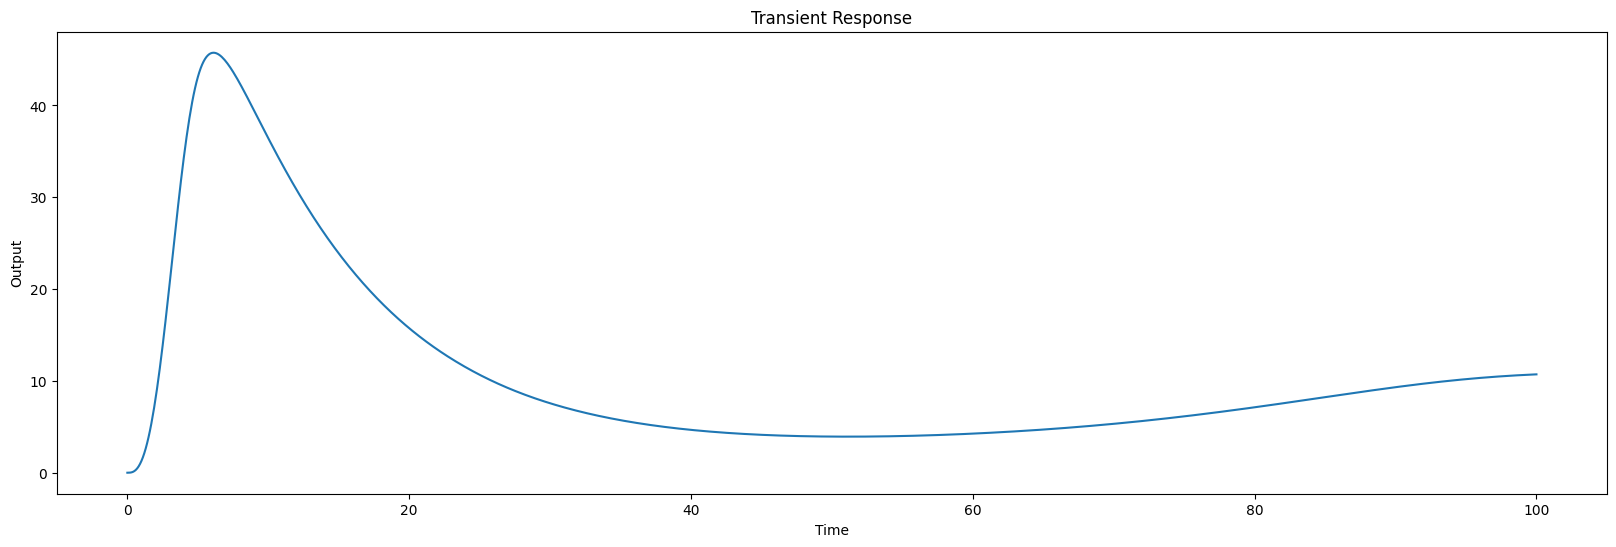

In [11]:
# Design the loss function
def Performance_Metric(self, r, y):
    return np.linalg.norm(r - y) / np.sqrt(len(y))

def _compute_single_loss(args):
    self, p, r, initial_condition, time_horizon = args
    local_IOCRN = self.IOCRN.clone()  # Ensure thread safety
    local_IOCRN.parameters = p
    y = local_IOCRN.transient_response(u, initial_condition, time_horizon)
    return self.Performance_Metric(r, y[0])

def compute_loss(self, r, initial_condition, time_horizon, h0, c0, manifold_dim):
    indices, total_logP, total_entropy, h, c = self.forward(h0, c0, manifold_dim)
    parameter = map_index_to_parameter(indices, self.parameter_grid)
    
    # Get maximum number of process workers
    with Pool(mp.cpu_count()) as pool:
        loss_for_each_sample = pool.map(
            _compute_single_loss,
            [(self, p, r, initial_condition, time_horizon) for p in parameter.T]
        )

    loss_for_each_sample = torch.tensor(loss_for_each_sample).to(h0)
    loss_mean = torch.mean(loss_for_each_sample)

    return loss_for_each_sample, loss_mean, total_logP, total_entropy, parameter

# Hyperparameters
N_grid = 100                             # Number of grid points for the parameter range
N_samples = 128*5                       # Number of samples to generate for Monte Carlo estimations
entropy_weight = 0.25                   # Initial Entropy weight for the loss function
entropy_update_coefficient = 0.9        # Coefficient for updating the entropy weight
entropy_schedule = 10                   # Number of epochs before updating the entropy weight
minimum_entropy_weight = 0.01           # Minimum entropy weight
num_epochs = 5000                       # Number of epochs to train the model
learning_rate = 1e-3                    # Learning rate for the optimizer   
t_final = 100                            # Final time for the simulation

# Construct an IOCRN modeling a Gene Expression process controlled by the AIF controller
stoichiometry_reactants = np.array([[0, 1, 1, 0, 0, 0, 0], [0, 0, 0, 1, 0, 1, 0], [1, 0, 0, 0, 0, 0, 1], [0, 0, 0, 0, 0, 0, 1]], dtype=np.int8)
stoichiometry_products = np.array([[1, 1, 0, 0, 0, 0, 0], [0, 1, 0, 0, 0, 1, 0], [1, 0, 0, 0, 1, 0, 0], [0, 0, 0, 0, 0, 1, 0]], dtype=np.int8)
k = 1; k_1 = 1; gamma_1 = 1; gamma_2 = 0.1; mu = 10; theta = 1; eta = 0.1
parameters = np.array([k, k_1, gamma_1, gamma_2, mu, theta, eta], dtype=np.float32)
input_influence_matrix = np.array([[0, 0, 0, 0, 1, 0, 0]], dtype=np.int8)
outputs = np.array([2], dtype=np.int8)
IOCRN_AIF = IOCRN_MassAction(stoichiometry_reactants, stoichiometry_products, parameters, input_influence_matrix, outputs)
species = ['X_1', 'X_2', 'Z_1', 'Z_2']
inputs = ['u']
IOCRN_AIF.print_reactions(species, inputs)

# Transient Response for the AIF Controller
u = np.array([1])
initial_condition = np.array([0, 0, 0, 0], dtype=np.float32)
time_horizon = np.linspace(0, t_final, 1000, dtype=np.float32)

tic = time.time()
outputs_AIF_transient = IOCRN_AIF.transient_response(u, initial_condition, time_horizon)
toc = time.time()
print('Simulation Time: %.2f' % (toc - tic))

plt.figure(figsize=(20, 6))
plt.subplot(1, 1, 1)
for i in range(len(outputs_AIF_transient)):
    plt.plot(time_horizon, outputs_AIF_transient[i])
plt.xlabel('Time')
plt.ylabel('Output')
plt.title('Transient Response')

print(np.linalg.norm(10 - outputs_AIF_transient[0]) / np.sqrt(len(outputs_AIF_transient[0])))

# Construct the parameter grid
param_1 = np.linspace(0.01, 20, N_grid, dtype=np.float32)
param_2 = np.linspace(0.01, 20, N_grid, dtype=np.float32)
param_3 = np.linspace(0.01, 20, N_grid, dtype=np.float32)
parameter_grid = np.stack([param_1, param_2, param_3], axis=0)

# Construct the CRN Generator
num_species = 4
num_reactions = 2
num_inputs = 1

# Define RSG_Attributes
class RSG_Attributes:
	LSTM_hidden_size = 128
	FFNN_hidden_size = [128, 128, 128]
	FFNN_num_layers = [5, 5, 5]
	weight = [None, None, None]

# Define PSG_Attributes
class PSG_Attributes:
	LSTM_hidden_size = 128
	FFNN_hidden_size = 128
	FFNN_num_layers = 5
	weight = None

# Design the loss function
def Performance_Metric(r, y):
    # return np.linalg.norm(r - y) / np.sqrt(len(y)) # + np.abs(y[-1] - r)
    return np.square(r - y).sum()/len(y)

def SS_Metric(r, y_ss):
    return np.abs(r - y_ss)

def unzip(params):
    out = []
    for i in range(len(params[0])):
        out.append([ p[i] for p in params ])
    return out

def _compute_single_loss(args):
    network_outputs, r, initial_condition, time_horizon, CRN_Fixed = args
    stoichiometry_reactants, stoichiometry_products, input_influence_matrix, parameter = network_outputs
    S_R = np.concatenate((CRN_Fixed.stoichiometry_reactants, stoichiometry_reactants), axis=1)
    S_P = np.concatenate((CRN_Fixed.stoichiometry_products, stoichiometry_products),  axis=1)
    S_I = np.concatenate((CRN_Fixed.input_influence_matrix, input_influence_matrix), axis=1)
    parameter = np.concatenate((CRN_Fixed.parameters, parameter[:-1]),axis=0)
    parameter[5] = parameter[-1]

    local_IOCRN = IOCRN_MassAction(S_R, S_P, parameter, S_I, np.array([2], dtype=np.int8))

    # make this line silent
    y, x = local_IOCRN.transient_response(u, initial_condition, time_horizon, return_states=True)
    
    y = np.minimum(y, 1000)
    y=np.maximum(y,0)
    y[np.isnan(y)] = 1000
    y[np.isinf(y)] = 1000
    # y_ss = local_IOCRN.dose_response(inputs, x[-1,:], plot_flag = False, axis=None)

    return Performance_Metric(r, y[0])



def compute_loss(self, r, initial_condition, time_horizon, h0, c0, manifold_dim, CRN_Fixed):
    network_outputs = self.forward(h0, c0, manifold_dim)
    stoichiometry_reactants, stoichiometry_products, input_influence_matrix, parameter, total_logP, total_entropy, h, c = network_outputs
    network_outputs=stoichiometry_reactants, stoichiometry_products, input_influence_matrix, parameter.T
    network_outputs = unzip(network_outputs)

    # Get maximum number of process workers\
    n_threads = mp.cpu_count()
    with Pool(mp.cpu_count()) as pool:
        loss_for_each_sample = pool.map(
            _compute_single_loss,
            [(no, r, initial_condition, time_horizon, CRN_Fixed) for no in network_outputs]
        )

    loss_for_each_sample = torch.tensor(loss_for_each_sample).to(h0)
    loss_mean = torch.mean(loss_for_each_sample)

    return loss_for_each_sample, loss_mean, total_logP, total_entropy

# MyCRN_Generator.Performance_Metric = types.MethodType(Performance_Metric, MyCRN_Generator)
# MyCRN_Generator.compute_loss = types.MethodType(compute_loss, MyCRN_Generator)

In [30]:
MyCRN_Generator = CRNGenerator(num_species, num_reactions, 1, num_inputs, parameter_grid, N_samples, RSG_Attributes, PSG_Attributes).to(device)

MyCRN_Generator.load_state_dict(torch.load('SavedModels/WeirdCRN_e5000.pt'))

<All keys matched successfully>

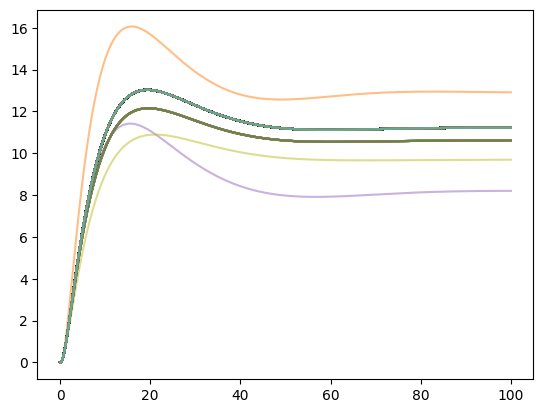

In [21]:
# Test the trained model
h0 = torch.ones(MyCRN_Generator.num_samples, RSG_Attributes.LSTM_hidden_size).float().to(device)
c0 = torch.ones(MyCRN_Generator.num_samples, RSG_Attributes.LSTM_hidden_size).float().to(device)
r = 10.
manifold_dim = 0
stoichiometry_reactants, stoichiometry_products, input_influence_matrix, parameter, _, _, _, _= MyCRN_Generator(h0, c0, manifold_dim)

# Transient Response for the AIF Controller
u = np.array([1])
initial_condition = np.array([0, 0, 0, 0], dtype=np.float32)
time_horizon = np.linspace(0, t_final, 1000, dtype=np.float32)

IOCRN_APIDF2 = np.empty(MyCRN_Generator.num_samples, dtype=IOCRN_MassAction)
Performance = np.empty(MyCRN_Generator.num_samples)
for i in range(MyCRN_Generator.num_samples):
    S_R = np.concatenate((IOCRN_AIF.stoichiometry_reactants, stoichiometry_reactants[i,:,:]), axis=1)
    S_P = np.concatenate((IOCRN_AIF.stoichiometry_products, stoichiometry_products[i,:,:]),  axis=1)
    S_I = np.concatenate((IOCRN_AIF.input_influence_matrix, input_influence_matrix[i,:,:]), axis=1)
    p = np.concatenate((IOCRN_AIF.parameters, parameter[:-1, i]),axis=0)
    p[5] = parameter[-1, i]
    IOCRN_APIDF2[i] = IOCRN_MassAction(S_R, S_P, p, S_I, np.array([2], dtype=np.int8))
    outputs_transient = IOCRN_APIDF2[i].transient_response(u, initial_condition, time_horizon)
    plt.plot(time_horizon, outputs_transient[0], alpha=0.5)
    Performance[i] = Performance_Metric(r, outputs_transient[0])

# Sort the performance in ascending order
indices = np.argsort(Performance)

Inputs: ['u']
Species: ['X_1', 'X_2', 'Z_1', 'Z_2']
Output Species: ['X_2']
Reaction 1: Z_1 -> X_1 + Z_1 ; Rate Constant: 1.0
Reaction 2: X_1 -> X_1 + X_2 ; Rate Constant: 1.0
Reaction 3: X_1 -> 0 ; Rate Constant: 1.0
Reaction 4: X_2 -> 0 ; Rate Constant: 0.10000000149011612
Reaction 5: 0 -> Z_1 ; Rate Constant: 10.0u
Reaction 6: X_2 -> X_2 + Z_2 ; Rate Constant: 0.6157575845718384
Reaction 7: Z_1 + Z_2 -> 0 ; Rate Constant: 0.10000000149011612
Reaction 8: 2 Z_1 -> Z_2 ; Rate Constant: 1.019595980644226u
Reaction 9: 2 Z_1 -> 0 ; Rate Constant: 0.6157575845718384u


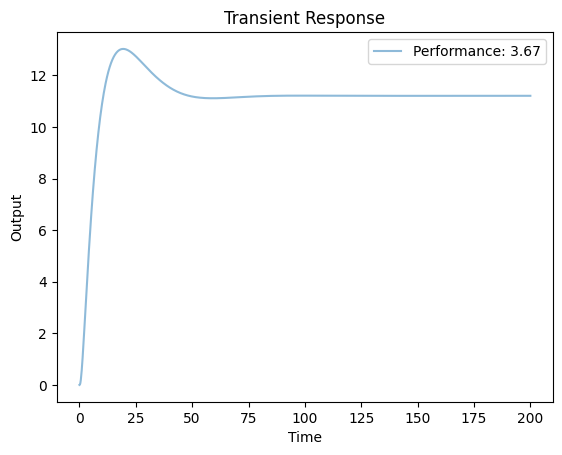

In [29]:
i = 0
IOCRN_APIDF2[indices[i]].print_reactions(species, inputs)

time_horizon = np.linspace(0, t_final+100, 1000, dtype=np.float32)

S_R = np.concatenate((IOCRN_AIF.stoichiometry_reactants, stoichiometry_reactants[i,:,:]), axis=1)
S_P = np.concatenate((IOCRN_AIF.stoichiometry_products, stoichiometry_products[i,:,:]),  axis=1)
S_I = np.concatenate((IOCRN_AIF.input_influence_matrix, input_influence_matrix[i,:,:]), axis=1)
p = np.concatenate((IOCRN_AIF.parameters, parameter[:-1, i]),axis=0)
p[5] = parameter[-1, i]
IOCRN_APIDF2_Picked = IOCRN_MassAction(S_R, S_P, p, S_I, np.array([2], dtype=np.int8))
outputs_transient = IOCRN_APIDF2_Picked.transient_response(u, initial_condition, time_horizon)
plt.plot(time_horizon, outputs_transient[0], alpha=0.5, label='Performance: %.2f' % Performance[indices[i]])
plt.xlabel('Time')
plt.ylabel('Output')
plt.title('Transient Response')
plt.legend()